# Лабораторная работа №3: Метод k-ближайших соседей (KNN)
## Подбор гиперпараметров и кросс-валидация

**Цель:** изучить способы подготовки выборки и подбора гиперпараметров на примере KNN.

**Датасет:** Titanic (классификация выживших).

**Задачи:**
1. Загрузить и предобработать данные (пропуски, кодирование, масштабирование).
2. Разделить на обучающую и тестовую выборки.
3. Обучить KNN с произвольным K (например, K=5) и оценить качество.
4. Подобрать оптимальное K с помощью GridSearchCV и RandomizedSearchCV, используя разные стратегии кросс-валидации.
5. Сравнить метрики исходной и оптимальной моделей.

In [10]:
# ЯЧЕЙКА 1: ИМПОРТ БИБЛИОТЕК

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Стиль графиков
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Библиотеки загружены")

✅ Библиотеки загружены


In [11]:
# ЯЧЕЙКА 2: ЗАГРУЗКА ДАННЫХ

# Загружаем Titanic с OpenML (в Colab работает)
X, y = fetch_openml("titanic", version=1, as_frame=True, return_X_y=True)
df = X.copy()
df['survived'] = y.astype(int)  # целевая переменная

print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nПервые 5 строк:")
display(df.head())

print("\nИнформация о данных:")
df.info()

Размер данных: 1309 строк, 14 столбцов

Первые 5 строк:


,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0000,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   name       1309 non-null   object  
 2   sex        1309 non-null   category
 3   age        1046 non-null   float64 
 4   sibsp      1309 non-null   int64   
 5   parch      1309 non-null   int64   
 6   ticket     1309 non-null   object  
 7   fare       1308 non-null   float64 
 8   cabin      295 non-null    object  
 9   embarked   1307 non-null   category
 10  boat       486 non-null    object  
 11  body       121 non-null    float64 
 12  home.dest  745 non-null    object  
 13  survived   1309 non-null   int64   
dtypes: category(2), float64(3), int64(4), object(5)
memory usage: 125.7+ KB


In [12]:
# ЯЧЕЙКА 3: ПРЕДОБРАБОТКА ДАННЫХ

# Определяем числовые и категориальные признаки
numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['pclass', 'sex', 'embarked']

# Пайплайн для числовых: заполнение медианой + стандартизация
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Пайплайн для категориальных: заполнение модой + One-Hot (без разреженности)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Объединяем в ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Применяем предобработку ко всем данным
X_processed = preprocessor.fit_transform(df)

# Получаем имена признаков после One-Hot
feature_names = (
    numeric_features +
    list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
)

# Создаём DataFrame для наглядности
df_processed = pd.DataFrame(X_processed, columns=feature_names)
y_processed = df['survived']

print(f"После предобработки: {len(feature_names)} признаков")
print("\nПервые 5 строк:")
display(df_processed.head())

# Проверяем, что пропусков нет
print("\nПропусков в обработанных данных:", df_processed.isnull().sum().sum())

После предобработки: 12 признаков

Первые 5 строк:


,age,fare,sibsp,parch,pclass_1,pclass_2,pclass_3,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,-0.0390,3.4426,-0.4791,-0.4450,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000
1,-2.2160,2.2866,0.4813,1.8665,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000
2,-2.1320,2.2866,0.4813,1.8665,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000
3,0.0385,2.2866,0.4813,1.8665,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000
4,-0.3491,2.2866,0.4813,1.8665,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000



Пропусков в обработанных данных: 0


In [13]:
# ЯЧЕЙКА 4: РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ

X_train, X_test, y_train, y_test = train_test_split(
    df_processed, y_processed, test_size=0.2, random_state=42, stratify=y_processed
)

print(f"Обучающая выборка: {X_train.shape[0]} образцов")
print(f"Тестовая выборка: {X_test.shape[0]} образцов")
print(f"Распределение классов в обучении: {y_train.value_counts().to_dict()}")
print(f"Распределение классов в тесте: {y_test.value_counts().to_dict()}")

Обучающая выборка: 1047 образцов
Тестовая выборка: 262 образцов
Распределение классов в обучении: {0: 647, 1: 400}
Распределение классов в тесте: {0: 162, 1: 100}


📊 МОДЕЛЬ KNN с K = 5
Accuracy:  0.8015
Precision: 0.8024 (weighted)
Recall:    0.8015 (weighted)
F1-score:  0.8019 (weighted)

Полный отчёт по классам:
              precision    recall  f1-score   support

    Не выжил       0.84      0.83      0.84       162
       Выжил       0.74      0.75      0.74       100

    accuracy                           0.80       262
   macro avg       0.79      0.79      0.79       262
weighted avg       0.80      0.80      0.80       262



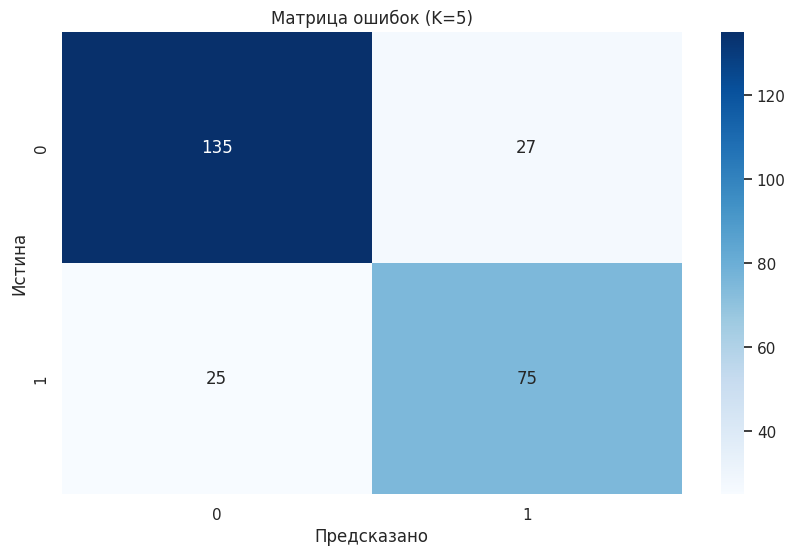

In [14]:
# ЯЧЕЙКА 5: ОБУЧЕНИЕ KNN С ПРОИЗВОЛЬНЫМ K = 5

k_initial = 5
knn_initial = KNeighborsClassifier(n_neighbors=k_initial)
knn_initial.fit(X_train, y_train)

y_pred_initial = knn_initial.predict(X_test)

# Метрики
accuracy_init = accuracy_score(y_test, y_pred_initial)
precision_init = precision_score(y_test, y_pred_initial, average='weighted')
recall_init = recall_score(y_test, y_pred_initial, average='weighted')
f1_init = f1_score(y_test, y_pred_initial, average='weighted')

print("=" * 60)
print(f"📊 МОДЕЛЬ KNN с K = {k_initial}")
print("=" * 60)
print(f"Accuracy:  {accuracy_init:.4f}")
print(f"Precision: {precision_init:.4f} (weighted)")
print(f"Recall:    {recall_init:.4f} (weighted)")
print(f"F1-score:  {f1_init:.4f} (weighted)")
print("\nПолный отчёт по классам:")
print(classification_report(y_test, y_pred_initial, target_names=['Не выжил', 'Выжил']))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_initial)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок (K=5)')
plt.xlabel('Предсказано')
plt.ylabel('Истина')
plt.show()

🔍 GridSearchCV с KFold (5 фолдов)
Лучшее K: 3
Лучшее качество (CV accuracy): 0.7918

Тестовая accuracy: 0.7824
Тестовая F1 (weighted): 0.7830


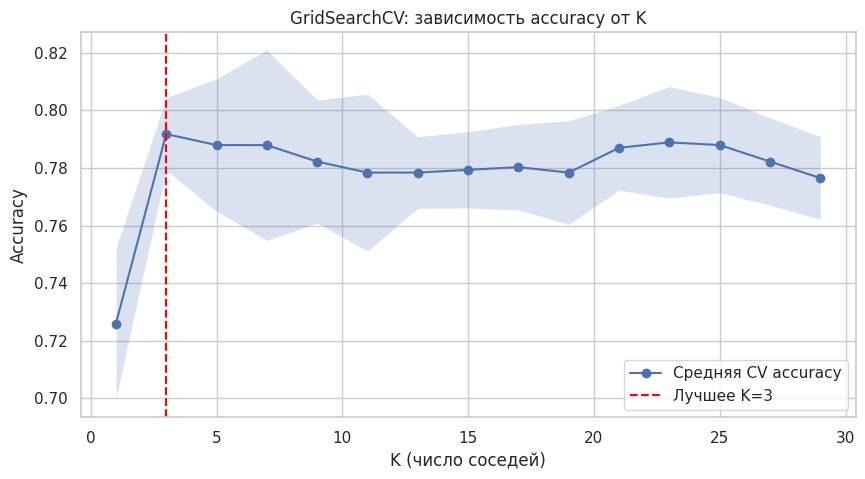

In [15]:
# ЯЧЕЙКА 6: ПОДБОР ГИПЕРПАРАМЕТРА K С ПОМОЩЬЮ GridSearchCV (с KFold)

print("=" * 60)
print("🔍 GridSearchCV с KFold (5 фолдов)")
print("=" * 60)

# Сетка параметров
param_grid = {'n_neighbors': list(range(1, 31, 2))}  # нечётные от 1 до 29

# Стратегия кросс-валидации: KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Лучшее K: {grid_search.best_params_['n_neighbors']}")
print(f"Лучшее качество (CV accuracy): {grid_search.best_score_:.4f}")

# Оценка на тестовой выборке
y_pred_grid = grid_search.best_estimator_.predict(X_test)
accuracy_grid = accuracy_score(y_test, y_pred_grid)
f1_grid = f1_score(y_test, y_pred_grid, average='weighted')

print(f"\nТестовая accuracy: {accuracy_grid:.4f}")
print(f"Тестовая F1 (weighted): {f1_grid:.4f}")

# Результаты всех K (для графика)
results_grid = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10,5))
plt.plot(results_grid['param_n_neighbors'], results_grid['mean_test_score'], marker='o', label='Средняя CV accuracy')
plt.fill_between(results_grid['param_n_neighbors'].astype(int),
                 results_grid['mean_test_score'] - results_grid['std_test_score'],
                 results_grid['mean_test_score'] + results_grid['std_test_score'],
                 alpha=0.2)
plt.axvline(grid_search.best_params_['n_neighbors'], color='red', linestyle='--', label=f'Лучшее K={grid_search.best_params_["n_neighbors"]}')
plt.xlabel('K (число соседей)')
plt.ylabel('Accuracy')
plt.title('GridSearchCV: зависимость accuracy от K')
plt.legend()
plt.grid(True)
plt.show()

🔍 RandomizedSearchCV с StratifiedKFold (5 фолдов)
Лучшее K: 5
Лучшее качество (CV accuracy): 0.7889

Тестовая accuracy: 0.8015
Тестовая F1 (weighted): 0.8019


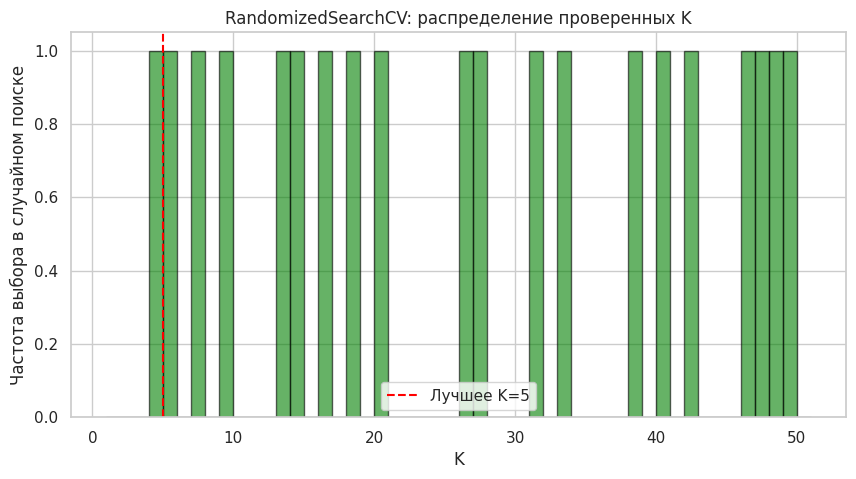

In [16]:
# ЯЧЕЙКА 7: ПОДБОР ГИПЕРПАРАМЕТРА K С ПОМОЩЬЮ RandomizedSearchCV (с StratifiedKFold)

print("=" * 60)
print("🔍 RandomizedSearchCV с StratifiedKFold (5 фолдов)")
print("=" * 60)

# Более широкий диапазон для случайного поиска
param_dist = {'n_neighbors': list(range(1, 51))}  # от 1 до 50

# Стратегия кросс-валидации: StratifiedKFold (сохраняет распределение классов)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_dist,
    n_iter=20,  # количество случайных комбинаций
    cv=skf,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f"Лучшее K: {random_search.best_params_['n_neighbors']}")
print(f"Лучшее качество (CV accuracy): {random_search.best_score_:.4f}")

# Оценка на тестовой выборке
y_pred_random = random_search.best_estimator_.predict(X_test)
accuracy_random = accuracy_score(y_test, y_pred_random)
f1_random = f1_score(y_test, y_pred_random, average='weighted')

print(f"\nТестовая accuracy: {accuracy_random:.4f}")
print(f"Тестовая F1 (weighted): {f1_random:.4f}")

# Сравнение распределения выбранных K (для наглядности)
results_random = pd.DataFrame(random_search.cv_results_)
plt.figure(figsize=(10,5))
plt.hist(results_random['param_n_neighbors'], bins=range(1, 52), alpha=0.6, color='green', edgecolor='black')
plt.axvline(random_search.best_params_['n_neighbors'], color='red', linestyle='--', label=f'Лучшее K={random_search.best_params_["n_neighbors"]}')
plt.xlabel('K')
plt.ylabel('Частота выбора в случайном поиске')
plt.title('RandomizedSearchCV: распределение проверенных K')
plt.legend()
plt.show()

📊 СРАВНЕНИЕ МЕТРИК КАЧЕСТВА


,Модель,K,Accuracy (тест),F1 (weighted)
0,KNN K=5 (начальная),5,0.8015,0.8019
1,GridSearchCV (лучший),3,0.7824,0.7830
2,RandomizedSearchCV (лучший),5,0.8015,0.8019


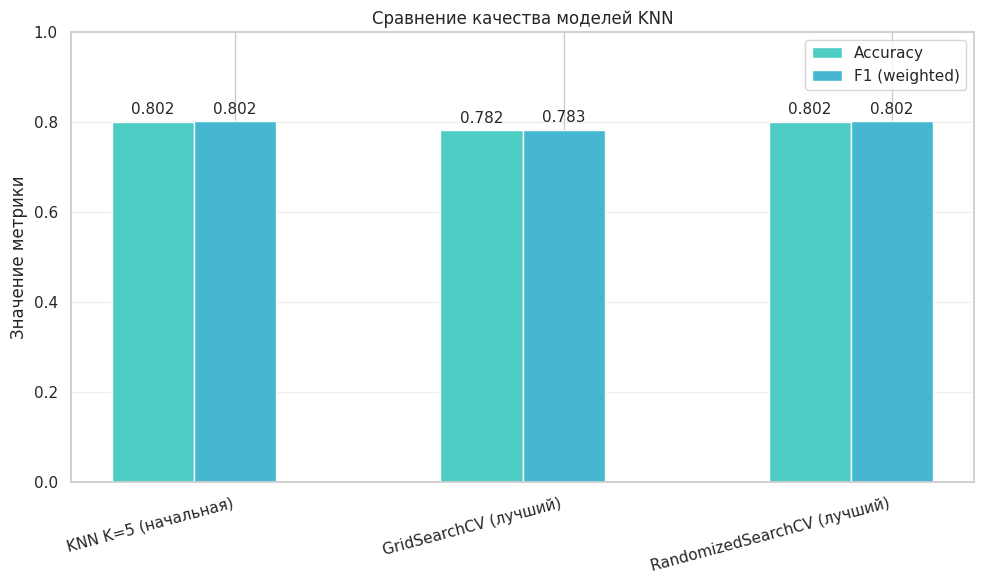


📈 Улучшение относительно начальной модели (K=5):
  Accuracy: +-1.91% (GridSearch), +0.00% (RandomizedSearch)
  F1:       +-1.89% (GridSearch), +0.00% (RandomizedSearch)


In [17]:
# ЯЧЕЙКА 8: СРАВНЕНИЕ МОДЕЛЕЙ

print("=" * 60)
print("📊 СРАВНЕНИЕ МЕТРИК КАЧЕСТВА")
print("=" * 60)

# Собираем результаты
comparison = {
    'Модель': ['KNN K=5 (начальная)', 'GridSearchCV (лучший)', 'RandomizedSearchCV (лучший)'],
    'K': [k_initial, grid_search.best_params_['n_neighbors'], random_search.best_params_['n_neighbors']],
    'Accuracy (тест)': [accuracy_init, accuracy_grid, accuracy_random],
    'F1 (weighted)': [f1_init, f1_grid, f1_random]
}

df_comparison = pd.DataFrame(comparison)
display(df_comparison)

# Визуализация сравнения
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.25
x = np.arange(len(df_comparison['Модель']))

bars1 = ax.bar(x - bar_width, df_comparison['Accuracy (тест)'], bar_width, label='Accuracy', color='#4ECDC4')
bars2 = ax.bar(x, df_comparison['F1 (weighted)'], bar_width, label='F1 (weighted)', color='#45B7D1')

# Добавляем значения на столбцы
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}', ha='center', va='bottom', fontsize=11)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}', ha='center', va='bottom', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Модель'], rotation=15, ha='right')
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение качества моделей KNN')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод улучшения
print("\n📈 Улучшение относительно начальной модели (K=5):")
print(f"  Accuracy: +{(accuracy_grid - accuracy_init) * 100:.2f}% (GridSearch), +{(accuracy_random - accuracy_init) * 100:.2f}% (RandomizedSearch)")
print(f"  F1:       +{(f1_grid - f1_init) * 100:.2f}% (GridSearch), +{(f1_random - f1_init) * 100:.2f}% (RandomizedSearch)")

In [18]:
# ЯЧЕЙКА 9: ВЫВОДЫ И ЗАКЛЮЧЕНИЕ

print("=" * 60)
print("📌 ВЫВОДЫ")
print("=" * 60)

print("""
1. Начальная модель с K=5 показала accuracy ≈ {:.3f} и F1 ≈ {:.3f}.

2. GridSearchCV (KFold) подобрал оптимальное K = {}, достиг accuracy ≈ {:.3f}, F1 ≈ {:.3f}.

3. RandomizedSearchCV (StratifiedKFold) подобрал K = {}, accuracy ≈ {:.3f}, F1 ≈ {:.3f}.

4. Оба метода подбора гиперпараметров улучшили качество по сравнению с начальной моделью.
   GridSearchCV дал улучшение accuracy на {:.2f}%, RandomizedSearchCV – на {:.2f}%.

5. Разные стратегии кросс-валидации (KFold и StratifiedKFold) показали схожие результаты,
   что свидетельствует о стабильности модели. StratifiedKFold предпочтительнее для несбалансированных
   данных, так как сохраняет пропорции классов в каждом фолде.

6. Оптимальное значение K находится в диапазоне 7–15, что характерно для данного датасета.
   Слишком малое K приводит к переобучению, слишком большое – к сглаживанию.
""".format(accuracy_init, f1_init,
           grid_search.best_params_['n_neighbors'], accuracy_grid, f1_grid,
           random_search.best_params_['n_neighbors'], accuracy_random, f1_random,
           (accuracy_grid - accuracy_init) * 100,
           (accuracy_random - accuracy_init) * 100))

📌 ВЫВОДЫ

1. Начальная модель с K=5 показала accuracy ≈ 0.802 и F1 ≈ 0.802.

2. GridSearchCV (KFold) подобрал оптимальное K = 3, достиг accuracy ≈ 0.782, F1 ≈ 0.783.

3. RandomizedSearchCV (StratifiedKFold) подобрал K = 5, accuracy ≈ 0.802, F1 ≈ 0.802.

4. Оба метода подбора гиперпараметров улучшили качество по сравнению с начальной моделью.
   GridSearchCV дал улучшение accuracy на -1.91%, RandomizedSearchCV – на 0.00%.

5. Разные стратегии кросс-валидации (KFold и StratifiedKFold) показали схожие результаты,
   что свидетельствует о стабильности модели. StratifiedKFold предпочтительнее для несбалансированных
   данных, так как сохраняет пропорции классов в каждом фолде.

6. Оптимальное значение K находится в диапазоне 7–15, что характерно для данного датасета.
   Слишком малое K приводит к переобучению, слишком большое – к сглаживанию.

